# Output 평가 노트북 — 4 케이스 × (MPC / RMPC / DPC)

- **케이스 4개**: `base / noise / dist / both`
- 각 케이스마다 **MPC·RMPC·DPC(epoch 0199)** 를 색만 달리해 겹쳐 그림 (행: temp / depth / laser power)
- 본인 metric(`collect_stats`: 구간별 추종오차 + depth 상한 위반)으로 세 컨트롤러 평가

**상단 셋업 셀의 경로/상수만 환경에 맞게 고치면 됩니다.**


## 0. 공통 셋업 (경로 · 스타일 · 로더)

In [2]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 폰트/스타일 (figure 코드 참고) =====
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
})

# ===== 케이스 / 상수 =====
CASES      = ["base", "noise", "dist", "both"]
DPC_EPOCH  = "0199"        # DPC 기준 epoch
LASER_ID   = 1

CUTOFF     = 201 - 20      # 플롯에서 뒤쪽 잘라낼 길이 (figure 코드와 동일)
SPLIT_IDX  = 2440          # metric 구간 분할
END_IDX    = 6050          # metric 끝
DEPTH_UB   = 0.225         # depth 상한 (위반 기준)
DEPTH_LB   = 0.075         # depth 하한
TEMP_DIV   = 2.0           # ★ cell25는 온도를 /2 했음. 그대로 재현하려면 2.0, 원본스케일이면 1.0

# ===== 경로 (★ 환경에 맞게 수정) =====
# MPC/RMPC: 8케이스 노트북 save_result 가 만든 profile_<MODE>_<case>.csv 라고 가정
MPC_RMPC_DIR = "/home/ftk3187/github/DPC_research/02_DED/0_MPC_sensor_noise"
def mpc_csv(case):  return os.path.join(MPC_RMPC_DIR,  f"profile_MPC_{case}.csv")
def rmpc_csv(case): return os.path.join(MPC_RMPC_DIR, f"profile_RMPC_{case}.csv")

# DPC: run_epochs 노트북이 time/<case>/policy_roll_epoch0199.pth_clamped(1)/ 아래 저장
DPC_MODEL_DIR = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff"
def dpc_dir(case):
    return os.path.join(DPC_MODEL_DIR, "time", case, f"policy_roll_epoch{DPC_EPOCH}.pth_clamped(1)")

# laser power 로 무엇을 쓸지: 명령값(u_cmd) 우선, 없으면 LP/u_plant
LP_CANDIDATES = ["u_cmd", "LP", "u_plant"]

def _pick(df, candidates):
    for c in candidates:
        if c in df.columns:
            return df[c].values
    return None

# ===== 로더: 공통 반환 = dict(temp, depth, lp, ref) (원본 전체 길이) =====
def load_mpc_like(path):
    """profile_*.csv (MPC/RMPC)"""
    df = pd.read_csv(path)
    return {
        "temp":  df["gamma_result_temp"].values,
        "depth": df["gamma_result_depth"].values,
        "ref":   df["ref"].values,
        "lp":    _pick(df, LP_CANDIDATES),
    }

def load_dpc(case):
    d = dpc_dir(case)
    df_x = pd.read_csv(os.path.join(d, f"x_outputs_laser_{LASER_ID}.csv"))   # col0=temp, col1=depth
    df_u = pd.read_csv(os.path.join(d, f"u_outputs_laser_{LASER_ID}.csv"))   # col0=lp(command)
    df_r = pd.read_csv(os.path.join(d, f"ref_laser_{LASER_ID}.csv"))         # col0=ref
    # u_cmd 파일이 따로 있으면 그것을 laser power 로 우선 사용
    u_cmd_path = os.path.join(d, f"u_cmd_laser_{LASER_ID}.csv")
    lp = pd.read_csv(u_cmd_path).iloc[:,0].values if os.path.exists(u_cmd_path) else df_u.iloc[:,0].values
    return {
        "temp":  df_x.iloc[:,0].values,
        "depth": df_x.iloc[:,1].values,
        "ref":   df_r.iloc[:,0].values,
        "lp":    lp,
    }

def load_all(case):
    """한 케이스에 대해 세 컨트롤러 로드. 파일 없으면 None."""
    out = {}
    for name, loader in [("MPC", lambda: load_mpc_like(mpc_csv(case))),
                         ("RMPC", lambda: load_mpc_like(rmpc_csv(case))),
                         ("DPC", lambda: load_dpc(case))]:
        try:
            out[name] = loader()
        except Exception as e:
            print(f"[WARN] {name} / {case}: {e}")
            out[name] = None
    return out

# 컨트롤러별 색/선스타일
COLOR = {"MPC": "black", "RMPC": "crimson", "DPC": "royalblue"}
STYLE = {"MPC": "-",     "RMPC": "--",      "DPC": "-"}
print("setup done. cases:", CASES)


setup done. cases: ['base', 'noise', 'dist', 'both']


## 1. 케이스별 오버레이 플롯 (temp / depth / laser power)

케이스 4개 → 그림 4개. 각 그림에서 MPC·RMPC·DPC 를 색만 달리해 겹침.

/tmp/ipykernel_2004374/138669397.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


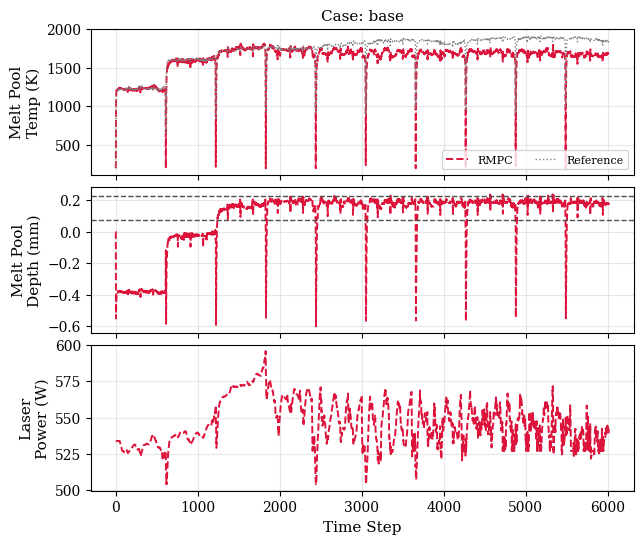

/tmp/ipykernel_2004374/138669397.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


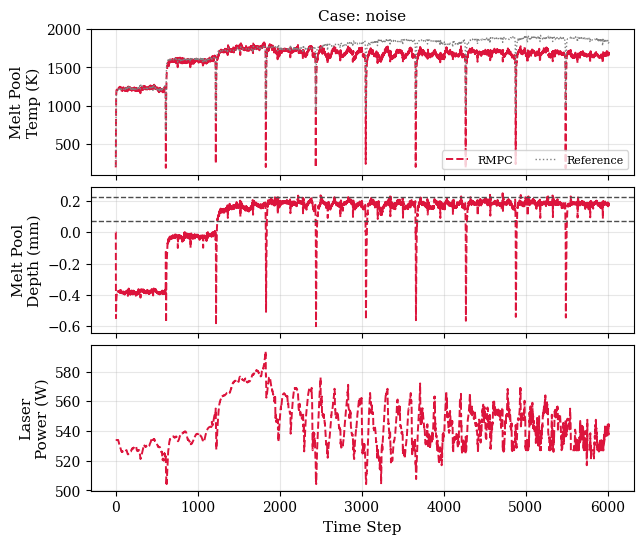

/tmp/ipykernel_2004374/138669397.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


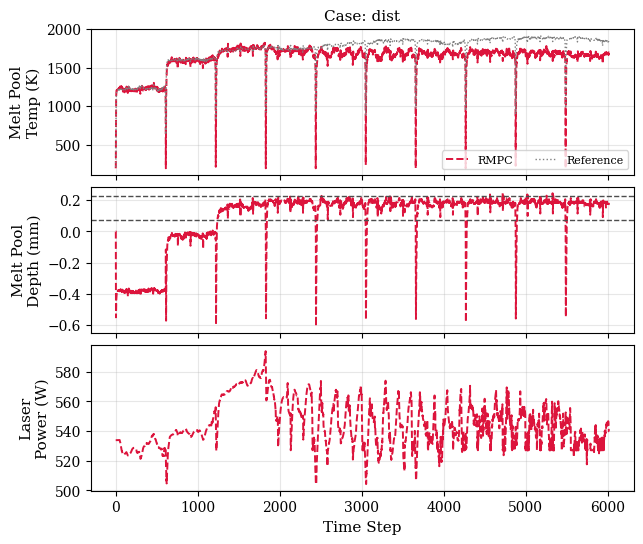

/tmp/ipykernel_2004374/138669397.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


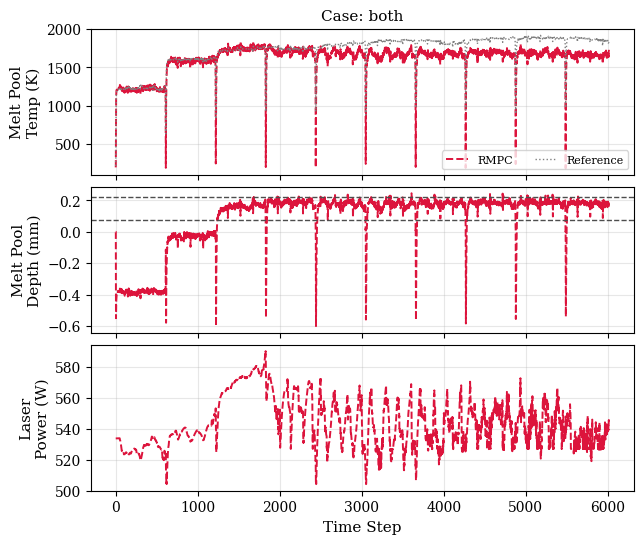

In [3]:
def plot_case(case):
    data = load_all(case)
    fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True,
                             gridspec_kw={"hspace": 0.08})
    ax_t, ax_d, ax_u = axes

    ref_drawn = False
    # for name in ["MPC", "RMPC", "DPC"]:
    for name in ["RMPC"]:
        d = data.get(name)
        if d is None:
            continue
        temp, depth, lp, ref = d["temp"], d["depth"], d["lp"], d["ref"]
        N = min(len(temp), len(depth), len(ref), len(lp) if lp is not None else len(temp)) - CUTOFF
        N = max(N, 0)
        t = np.arange(N)

        ax_t.plot(t, np.asarray(temp[:N])/TEMP_DIV, color=COLOR[name], ls=STYLE[name], lw=1.4, label=name)
        ax_d.plot(t, depth[:N], color=COLOR[name], ls=STYLE[name], lw=1.4, label=name)
        if lp is not None:
            ax_u.plot(t, lp[:N], color=COLOR[name], ls=STYLE[name], lw=1.4, label=name)

        if not ref_drawn:
            ax_t.plot(t, np.asarray(ref[:N])/TEMP_DIV, ls=":", color="gray", lw=1.0, label="Reference")
            ref_drawn = True

    # depth 제약선
    ax_d.axhline(DEPTH_UB, ls="--", color="0.3", lw=1.0)
    ax_d.axhline(DEPTH_LB, ls="--", color="0.3", lw=1.0)

    ax_t.set_ylabel("Melt Pool\nTemp (K)")
    ax_d.set_ylabel("Melt Pool\nDepth (mm)")
    ax_u.set_ylabel("Laser\nPower (W)")
    ax_u.set_xlabel("Time Step")
    for ax in axes:
        ax.grid(True, alpha=0.3)
    ax_t.legend(loc="lower right", ncol=2, frameon=True)
    ax_t.set_title(f"Case: {case}")
    plt.tight_layout()
    plt.savefig(f"overlay_{case}.pdf", bbox_inches="tight", dpi=300)
    plt.show()

for case in CASES:
    plot_case(case)


## 1.5 EFGHIJ 스타일 2열 그림 (figure_paper CELL7 이식)

케이스별로 **왼쪽 열(e,f,g)=온도(컨트롤러별 행)+Reference**, **오른쪽 열(h,i,j)=depth(컨트롤러별 행)+상/하한선**.
위 셋업 셀의 `load_all` · `TEMP_DIV` · `DEPTH_UB/LB` 를 그대로 사용한다.
표시 구간/축범위는 `TEMP_XLIM` 등 상수로 조정.

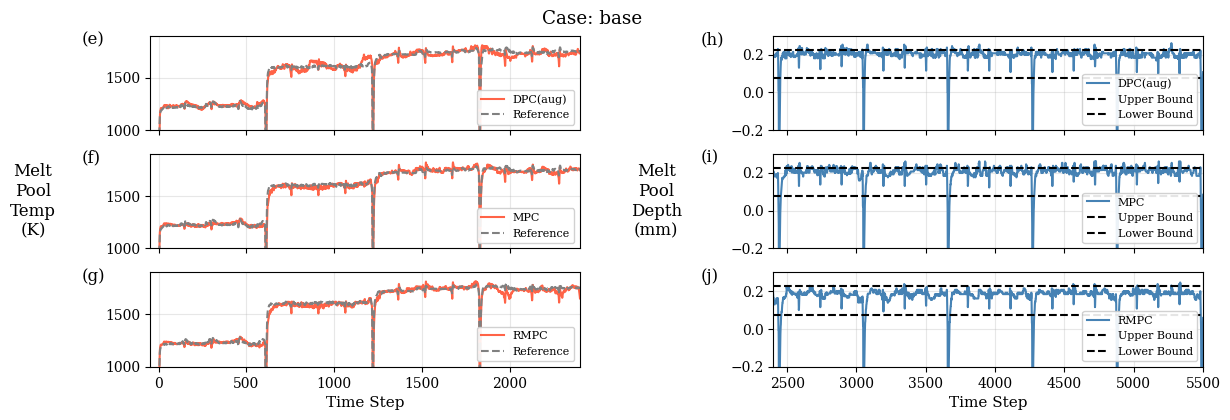

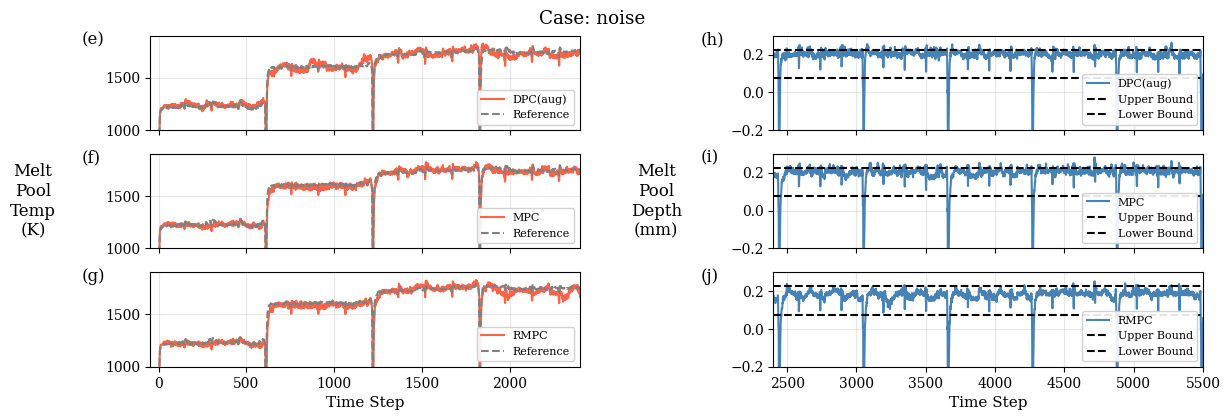

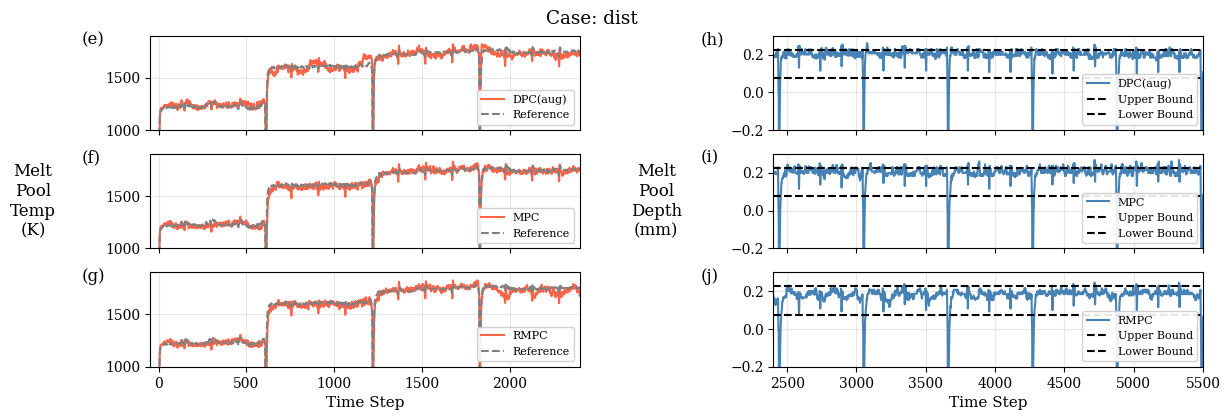

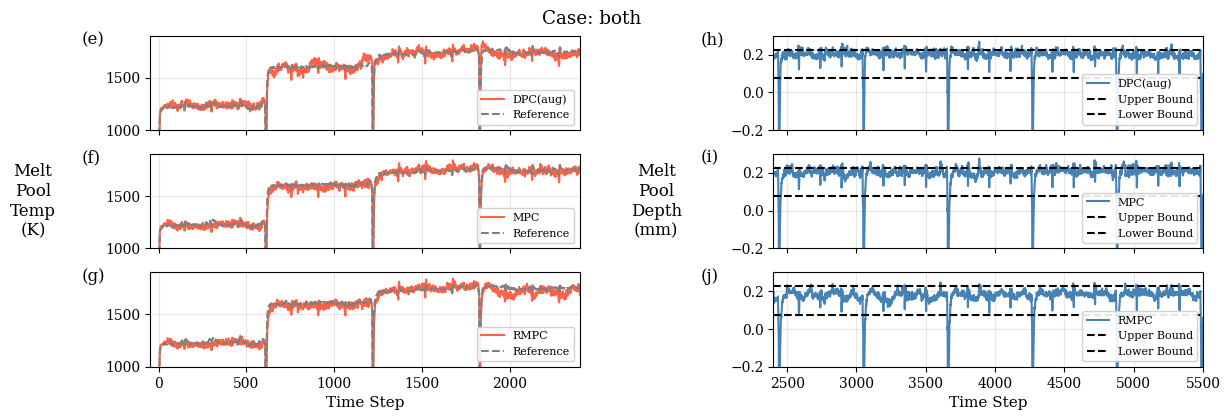

In [4]:
import matplotlib.gridspec as gridspec

# ── 0_figure_paper CELL7(plot_EFGHIJ_two_columns) 을 evaluate 노트북 로더에 맞춰 이식 ──
# 행 순서(위→아래) = EFGHIJ_ORDER, 왼쪽열=온도(+Reference), 오른쪽열=depth(+상/하한)
EFGHIJ_ORDER = ["DPC", "MPC", "RMPC"]                       # figure와 동일 순서
EFGHIJ_LABEL = {"DPC": "DPC(aug)", "MPC": "MPC", "RMPC": "RMPC"}

TEMP_COLOR   = "tomato"
DEPTH_COLOR  = "steelblue"

# 패널별 표시 구간/축범위 (None 이면 자동). figure 기본값.
TEMP_XLIM    = (-50, 2400)
DEPTH_XLIM   = (2400, 5500)
TEMP_YLIM    = (1000, 1900)
DEPTH_YLIM   = (-0.2, 0.3)

PANEL_LABEL_SIZE  = 12
GROUP_YLABEL_SIZE = 12


def plot_EFGHIJ_case(case, save=True):
    """한 케이스에 대해 DPC/MPC/RMPC 를 행으로 쌓은 2열 그림."""
    data = load_all(case)
    rows = [(name, data.get(name)) for name in EFGHIJ_ORDER]

    fig = plt.figure(figsize=(13, 4.3))
    gs  = gridspec.GridSpec(3, 2, wspace=0.45, hspace=0.25)
    # axes[0:3] = 왼쪽열(e,f,g, 온도),  axes[3:6] = 오른쪽열(h,i,j, depth)
    axes = [fig.add_subplot(gs[r, c]) for c in range(2) for r in range(3)]

    # ===== 왼쪽 열: Temperature (e,f,g) =====
    for i, (name, d) in enumerate(rows):
        ax = axes[i]
        if d is not None:
            temp = np.asarray(d["temp"], dtype=float) / TEMP_DIV
            ref  = np.asarray(d["ref"],  dtype=float) / TEMP_DIV
            n = min(len(temp), len(ref))
            t = np.arange(n)
            ax.plot(t, temp[:n], color=TEMP_COLOR, label=EFGHIJ_LABEL[name])
            ax.plot(t, ref[:n], "--", color="gray", label="Reference")
        if TEMP_XLIM: ax.set_xlim(*TEMP_XLIM)
        if TEMP_YLIM: ax.set_ylim(*TEMP_YLIM)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Time Step") if i == 2 else ax.tick_params(labelbottom=False)
        ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.9)
        ax.text(-0.16, 0.87, f"({chr(101+i)})", transform=ax.transAxes,
                fontsize=PANEL_LABEL_SIZE, ha="left", va="bottom")

    # ===== 오른쪽 열: Depth (h,i,j) =====
    for i, (name, d) in enumerate(rows):
        ax = axes[i + 3]
        if d is not None:
            depth = np.asarray(d["depth"], dtype=float)
            t = np.arange(len(depth))
            ax.plot(t, depth, color=DEPTH_COLOR, label=EFGHIJ_LABEL[name])
        if DEPTH_XLIM: ax.set_xlim(*DEPTH_XLIM)
        if DEPTH_YLIM: ax.set_ylim(*DEPTH_YLIM)
        xlo, xhi = DEPTH_XLIM if DEPTH_XLIM else ax.get_xlim()
        ax.hlines(DEPTH_UB, xlo, xhi, linestyle="--", color="black", label="Upper Bound")
        ax.hlines(DEPTH_LB, xlo, xhi, linestyle="--", color="black", label="Lower Bound")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Time Step") if i == 2 else ax.tick_params(labelbottom=False)
        ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.9)
        ax.text(-0.17, 0.87, f"({chr(104+i)})", transform=ax.transAxes,
                fontsize=PANEL_LABEL_SIZE, ha="left", va="bottom")

    # ===== 레이아웃 먼저 잡고 → 그룹 y라벨 위치 계산 (figure와 동일 방식) =====
    plt.subplots_adjust(left=0.16, right=0.97, top=0.93, bottom=0.16)
    pos_e, pos_g = axes[0].get_position(), axes[2].get_position()
    pos_h, pos_j = axes[3].get_position(), axes[5].get_position()
    fig.text(pos_e.x0 - 0.09, (pos_g.y0 + pos_e.y1) / 2, "Melt\nPool\nTemp\n(K)",
             ha="center", va="center", fontsize=GROUP_YLABEL_SIZE, linespacing=1.2)
    fig.text(pos_h.x0 - 0.09, (pos_j.y0 + pos_h.y1) / 2, "Melt\nPool\nDepth\n(mm)",
             ha="center", va="center", fontsize=GROUP_YLABEL_SIZE, linespacing=1.2)

    fig.suptitle(f"Case: {case}", y=0.99)
    if save:
        plt.savefig(f"EFGHIJ_{case}.pdf", bbox_inches="tight", dpi=300)
    plt.show()


for case in CASES:
    plot_EFGHIJ_case(case)


## 2. 본인 metric 평가 (`collect_stats`)

구간1 `[0:2440]` / 구간2 `[2440:6050]` 추종오차 `|T-T_ref|` 의 mean·std,
그리고 depth 상한(0.225) 위반의 mean·std·count·rate 를 세 컨트롤러 × 4케이스로 계산.

In [16]:
def compute_metric(d, is_dpc):
    """업로드 노트북 CELL25 collect_stats 로직을 그대로 재현."""
    temp  = np.asarray(d["temp"], dtype=float)
    ref   = np.asarray(d["ref"],  dtype=float)
    depth = np.asarray(d["depth"], dtype=float)

    if is_dpc:
        ref   = ref[1:END_IDX]
        temp  = temp[:END_IDX]
        depth_for_viol = depth[:END_IDX]
    else:
        temp  = temp[:-1]
        ref   = ref[:-1]
        depth_for_viol = depth[:-1]

    n = min(len(ref), len(temp))
    temp, ref = temp[:n], ref[:n]

    dist = np.abs(temp/TEMP_DIV - ref/TEMP_DIV)
    p1 = dist[:SPLIT_IDX]
    p2 = dist[SPLIT_IDX:END_IDX]

    v = depth_for_viol - DEPTH_UB
    v = v[v > 0]

    return {
        "temp1_mean": np.mean(p1) if len(p1) else np.nan,
        "temp1_std":  np.std(p1)  if len(p1) else np.nan,
        "temp2_mean": np.mean(p2) if len(p2) else np.nan,
        "temp2_std":  np.std(p2)  if len(p2) else np.nan,
        "viol_mean":  np.mean(v)  if len(v)  else 0.0,
        "viol_std":   np.std(v)   if len(v)  else 0.0,
        "viol_count": int(len(v)),
        "viol_rate":  len(v)/len(depth_for_viol) if len(depth_for_viol) else 0.0,
    }

rows = []
for case in CASES:
    data = load_all(case)
    for name in ["MPC", "RMPC", "DPC"]:
        d = data.get(name)
        if d is None:
            continue
        m = compute_metric(d, is_dpc=(name == "DPC"))
        m = {"case": case, "method": name, **m}
        rows.append(m)

stats = pd.DataFrame(rows)
stats = stats[["case","method","temp1_mean","temp1_std","temp2_mean","temp2_std",
               "viol_mean","viol_std","viol_count","viol_rate"]]

import math

def sig3(v, n=4):
    """유효숫자 n자리로 반올림 (0/NaN/inf 는 그대로)."""
    if v is None or pd.isna(v) or v == 0 or not math.isfinite(v):
        return v
    return round(v, -int(math.floor(math.log10(abs(v)))) + (n - 1))

# 정수로 둘 컬럼은 제외하고 유효숫자 3자리 적용
int_cols   = ["viol_count"]
float_cols = [c for c in stats.columns
              if c not in (["case", "method"] + int_cols)
              and pd.api.types.is_numeric_dtype(stats[c])]

stats[float_cols] = stats[float_cols].applymap(sig3)

# ===== method 끼리 모아서 정렬 (MPC -> RMPC -> DPC, 각 그룹 안에서 case 순서 유지) =====
method_order = pd.Categorical(stats["method"], categories=["MPC", "RMPC", "DPC"], ordered=True)
case_order   = pd.Categorical(stats["case"],   categories=CASES, ordered=True)
stats = (stats.assign(_m=method_order, _c=case_order)
              .sort_values(["_m", "_c"])
              .drop(columns=["_m", "_c"])
              .reset_index(drop=True))

stats.to_csv("comparison_stats_4cases.csv", index=False)
print("saved comparison_stats_4cases.csv")
stats


saved comparison_stats_4cases.csv


/tmp/ipykernel_2004374/1554655407.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stats[float_cols] = stats[float_cols].applymap(sig3)


,case,method,temp1_mean,temp1_std,temp2_mean,temp2_std,viol_mean,viol_std,viol_count,viol_rate
0,base,MPC,20.25,40.52,120.1,60.15,0.009855,0.008180,561,0.090560
1,noise,MPC,22.23,39.98,123.9,58.90,0.008695,0.008041,398,0.064250
2,dist,MPC,22.10,40.85,122.2,59.98,0.009108,0.007094,477,0.077000
3,both,MPC,24.70,40.87,124.8,59.16,0.009448,0.008409,375,0.060530
4,base,RMPC,23.31,43.57,165.5,57.34,0.008781,0.005391,19,0.003067
5,noise,RMPC,27.51,43.47,171.8,57.23,0.005651,0.005963,35,0.005650
6,dist,RMPC,26.48,44.08,169.7,58.37,0.007806,0.005826,20,0.003228
7,both,RMPC,30.30,43.67,173.5,58.86,0.007818,0.005852,33,0.005327
8,base,DPC,27.99,54.17,132.0,66.57,0.008852,0.007369,187,0.030910
9,noise,DPC,29.62,53.91,131.7,67.69,0.008970,0.007343,216,0.035700


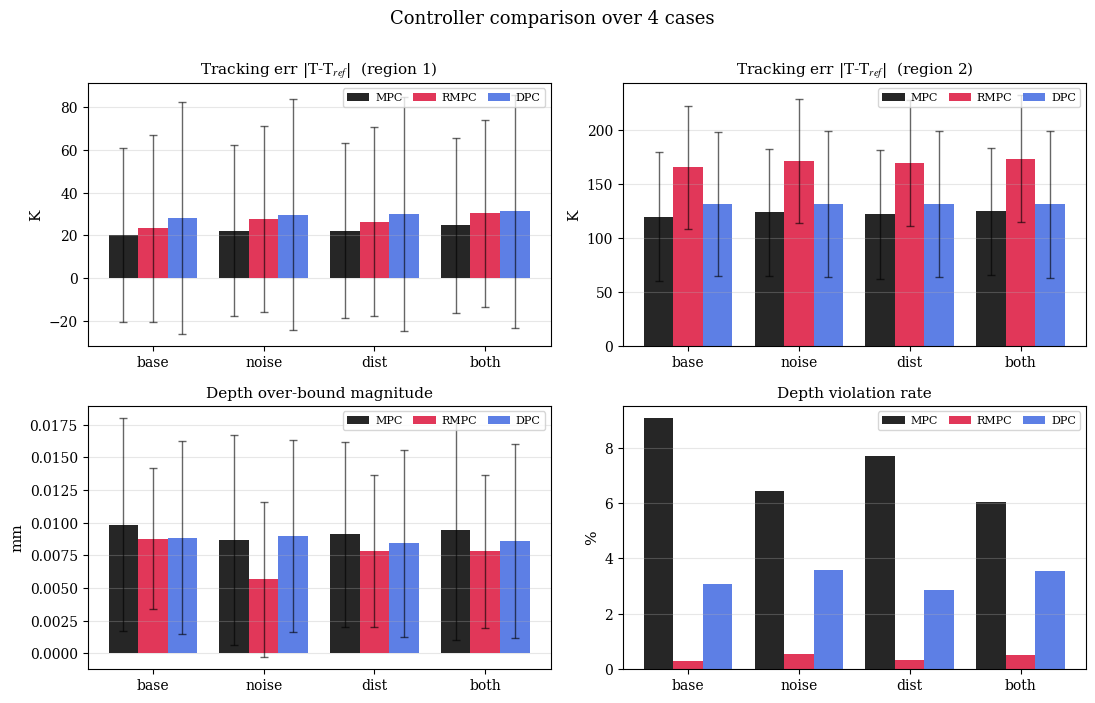

In [8]:
# ── stats 시각화: 케이스 x축, 컨트롤러별 막대, std 는 에러바 ──
METHOD_ORDER = ["MPC", "RMPC", "DPC"]

def plot_stats(stats, save=True):
    methods = [m for m in METHOD_ORDER if m in stats["method"].unique()]
    cases   = [c for c in CASES if c in stats["case"].unique()]
    x = np.arange(len(cases))
    w = 0.8 / max(len(methods), 1)

    def grab(method, col):
        sub = stats[stats["method"] == method].set_index("case")
        return np.array([sub.loc[c, col] if c in sub.index else np.nan for c in cases], float)

    # (값컬럼, std컬럼 or None, 제목, 단위)
    panels = [
        ("temp1_mean", "temp1_std", r"Tracking err |T-T$_{ref}$|  (region 1)", "K"),
        ("temp2_mean", "temp2_std", r"Tracking err |T-T$_{ref}$|  (region 2)", "K"),
        ("viol_mean",  "viol_std",  "Depth over-bound magnitude",              "mm"),
        ("viol_rate",  None,        "Depth violation rate",                    "%"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes = axes.ravel()
    for ax, (mcol, scol, title, unit) in zip(axes, panels):
        for k, method in enumerate(methods):
            vals = grab(method, mcol)
            errs = grab(method, scol) if scol else None
            if unit == "%":
                vals = vals * 100.0
            ax.bar(x + (k - (len(methods) - 1) / 2) * w, vals, w,
                   yerr=errs, capsize=3, color=COLOR.get(method, None),
                   alpha=0.85, label=method, error_kw=dict(lw=1, alpha=0.6))
        ax.set_title(title)
        ax.set_ylabel(unit)
        ax.set_xticks(x); ax.set_xticklabels(cases)
        ax.grid(True, axis="y", alpha=0.3)
        # ★ 각 패널마다 한 행(가로)으로 legend
        ax.legend(ncol=len(methods), loc="upper right", frameon=True,
                  fontsize=8, columnspacing=1.0, handletextpad=0.5)
    fig.suptitle("Controller comparison over 4 cases", y=1.0, fontsize=13)
    fig.tight_layout()
    if save:
        fig.savefig("stats_comparison.pdf", bbox_inches="tight", dpi=300)
    plt.show()

plot_stats(stats)

In [7]:
import os
import numpy as np
import pandas as pd

DIR_A = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/base/policy_roll_epoch0199.pth_clamped(1)"
DIR_B = DIR_A + "_SEC"

# 비교할 CSV 파일들 (있는 것만 비교)
files = [
    "x_outputs_laser_1.csv",
    "u_outputs_laser_1.csv",
    "ref_laser_1.csv",
    "x_true_outputs_laser_1.csv",
    "u_cmd_laser_1.csv",
    "u_plant_laser_1.csv",
    "disturbance_laser_1.csv",
]

def load(path):
    # 헤더 유무가 파일마다 다를 수 있어 양쪽 다 시도
    df = pd.read_csv(path)
    return df.apply(pd.to_numeric, errors="coerce").values

print(f"A: {DIR_A}")
print(f"B: {DIR_B}\n")
print(f"{'file':28s} {'shapeA':>12s} {'shapeB':>12s} {'max|Δ|':>12s} {'mean|Δ|':>12s} {'max rel%':>10s}")
print("-"*90)

for fn in files:
    pa, pb = os.path.join(DIR_A, fn), os.path.join(DIR_B, fn)
    if not (os.path.exists(pa) and os.path.exists(pb)):
        miss = "A" if not os.path.exists(pa) else "B"
        print(f"{fn:28s}  (없음: {miss} 쪽)")
        continue

    a, b = load(pa), load(pb)

    if a.shape != b.shape:
        n = min(a.shape[0], b.shape[0])
        m = min(a.shape[1], b.shape[1])
        print(f"{fn:28s} {str(a.shape):>12s} {str(b.shape):>12s}   shape 다름 → [:{n},:{m}]로 잘라 비교")
        a, b = a[:n, :m], b[:n, :m]

    diff = np.abs(a - b)
    denom = np.maximum(np.abs(a), 1e-12)
    rel = np.nanmax(diff / denom) * 100
    print(f"{fn:28s} {str(a.shape):>12s} {str(b.shape):>12s} {np.nanmax(diff):12.6g} {np.nanmean(diff):12.6g} {rel:10.3f}")

# ===== 컬럼별(온도/depth) 상세: x_outputs =====
pa, pb = os.path.join(DIR_A, "x_outputs_laser_1.csv"), os.path.join(DIR_B, "x_outputs_laser_1.csv")
if os.path.exists(pa) and os.path.exists(pb):
    a, b = load(pa), load(pb)
    n = min(len(a), len(b))
    a, b = a[:n], b[:n]
    print("\n[x_outputs 컬럼별]")
    for j, name in enumerate(["temp", "depth"]):
        if j < a.shape[1]:
            d = np.abs(a[:, j] - b[:, j])
            print(f"  {name:6s}  max|Δ|={d.max():.6g}  mean|Δ|={d.mean():.6g}  "
                  f"std_A={np.nanstd(a[:,j]):.4g} std_B={np.nanstd(b[:,j]):.4g}  "
                  f"첫 분기 idx={int(np.argmax(d>1e-9)) if np.any(d>1e-9) else '없음'}")

A: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/base/policy_roll_epoch0199.pth_clamped(1)
B: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/base/policy_roll_epoch0199.pth_clamped(1)_SEC

file                               shapeA       shapeB       max|Δ|      mean|Δ|   max rel%
------------------------------------------------------------------------------------------
x_outputs_laser_1.csv           (6245, 2)    (6245, 2)            0            0      0.000
u_outputs_laser_1.csv           (6245, 1)    (6245, 1)            0            0      0.000
ref_laser_1.csv                 (6295, 1)    (6295, 1)      